<a href="https://colab.research.google.com/github/Manav010203/Quiz/blob/cloudmain/02_pytorch_classfication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#02 Neural Network classfication with Pyorch
Classfication is a problem of predicting whether something is one thing or another (there can be multiple things to select from)
for example selecting whether it is a sushi , pizza , burger

#1 Make classification data and get it ready

In [85]:
import sklearn

In [86]:
device

'cuda'

In [87]:
from sklearn.datasets import make_circles


# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03, # a little bit of noise to the dots
                    random_state=42) # keep random state so we get the same values

In [88]:
len(X),len(y)

(1000, 1000)

In [89]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y labels:
[1 1 1 1 0]


In [90]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
    "X2": X[:, 1],
    "label": y
})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


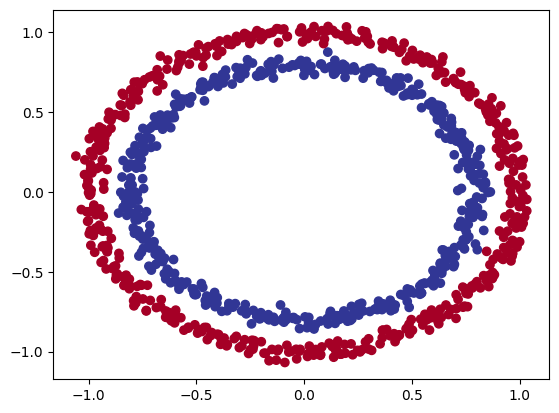

In [91]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu);

**Note** The data er are working with is often referred to as a toy dataset, a dataset that is small enough to experiment but still sizeable enough to practice the fudamentals.

###1.1 Check input and output shapes

In [92]:
X.shape,y.shape

((1000, 2), (1000,))

In [93]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [94]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


### 1.2 Turn into tensor and create train and test splits

In [95]:
import torch
torch.__version__

'2.6.0+cu124'

In [96]:
type(X),X.dtype

(numpy.ndarray, dtype('float64'))

In [97]:
# Turn data into tensors
# Otherwise this causes issues with computations later on
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# View the first five samples
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [98]:
type(X),X.dtype,y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [99]:
#split data into training and test sets
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test= train_test_split(X,
                                                y,
                                                test_size=0.2 ,# == 20% test and 80% train,
                                                random_state=42,
                                                )

In [100]:
len(X_train),len(X_test),len(y_train),len(y_test)

(800, 200, 800, 200)

### 2. Building model

lets build model to classify our blue and red dots

to do so , we want to:
1. Setup device agnostic code so our code will run on an accelerator (GPU) if there is one
2. construct a model (by subclassing nn.Module)
3. Define a loss function and optimizer
4. Create a training and test function

In [101]:
import torch
from torch import nn

In [102]:
## device agnostic code
device = "cpu" if not torch.cuda.is_available() else "cuda"
device

'cuda'

### CONSTRUCTING A MODEL
1. subclass `nn.Module` (almost all model is subclass of `nn.Module`)
2. Create 2 `nn.Linear()` layers that are cappable of handling the shapes of our data
3. Defines a `forward()` method that outlines the forward pass (or forward computation) of the model
4. Instatiate an instance of our model class and send it to the target device

In [103]:
# 1. construct a model that subclass  the 'nn.Module' class
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    #2 create 2 nn.Linear layer capapble of handling classification.
    self.Layer1 =nn.Linear(in_features=2,out_features=5) # takes 2 in and upscale it ot 5 features
    self.Layer2 = nn.Linear(in_features=5,out_features=1) #takes in 5 in and output 1 feature
#define forward method that outlines the forward pass
  def forward(self,x):
    return self.Layer2(self.Layer1(x)) #x -> layer1 -> layer2-> output


#4 instantiate an instance of our model classs and sed it to the target device
model_0 = CircleModelV0().to(device)
model_0



CircleModelV0(
  (Layer1): Linear(in_features=2, out_features=5, bias=True)
  (Layer2): Linear(in_features=5, out_features=1, bias=True)
)

In [104]:
device

'cuda'

In [105]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [106]:
#lets replicate the model abov using nn.Sequential()
model_0 = nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [107]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]], device='cuda:0')),
             ('0.bias',
              tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]], device='cuda:0')),
             ('1.bias', tensor([-0.1213], device='cuda:0'))])

In [108]:
#make some predictions with model
with torch.inference_mode():
  untrained_preds =model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}")
print(f"Shape of predictions: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}")
print(f"Shape of test samples: {X_test.shape}")
print(f"\n First 10 predictions: \n {untrained_preds[:10]}")
print(f"\n first 10 lables: \n {y_test[:10]}")

Length of predictions: 200
Shape of predictions: torch.Size([200, 1])
Length of test samples: 200
Shape of test samples: torch.Size([200, 2])

 First 10 predictions: 
 tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967],
        [ 0.2968],
        [ 0.1405],
        [ 0.2178],
        [ 0.0805],
        [-0.0284]], device='cuda:0')

 first 10 lables: 
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [109]:
X_test[:10],y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### 2.1 setup loss functiona and optimizer

which loss function to use ?

again... this is problem specific

for example for regression you might want MAE or MSE (mean absolute error or mean squared error )

For classification you might want to use binary cross entropy or categorical cross entropy (cross entropy).

As a reminder loss function is a function which measures how *wrong* is your model

In [110]:
##setup loss function
loss_fn = nn.BCEWithLogitsLoss() #sigmoid function involves


optimizer = torch.optim.SGD(params =model_0.parameters(),
                            lr = 0.1)

In [111]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]], device='cuda:0')),
             ('0.bias',
              tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]], device='cuda:0')),
             ('1.bias', tensor([-0.1213], device='cuda:0'))])

In [112]:
# Calculate accuracy - out of 100 examples, what percentage does our model get right?

# def accuracy_fn(y_true,y_pred):
#   correct = torch.eq(y_true,y_pred()).sum().item()
#   acc = (correct/len(y_pred))*100
#   return acc
  # Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return acc

###3. Training Model
to train our model we need to make a training Loop
1. forward pass
2. calculate loss
3. zero_grad
4. backp propagation
5. optimizer step

# 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to be raw logits

we can convert these logits into prediction probabilities by passing them through some kind of activation function (for example sigmoid for binary classification and softmax for multiclass classification)

Then we can convert our models predictio probabilities to prediction labels by either rounding them or taking the argmax().

In [113]:
# View the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():

  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]], device='cuda:0')

In [114]:
y_test[:5 ]

tensor([1., 0., 1., 0., 1.])

In [115]:
#use the sigmoid activation function on our model logits to turn them into prediction probabilities
y_pred_probs= torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]], device='cuda:0')

In [116]:
#find the predicted labels
y_preds = torch.round(y_pred_probs)

#in Full (logits->pred probs->pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

#check for equality
print(torch.eq(y_preds.squeeze(),y_pred_labels.squeeze()))
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 1., 0., 1.], device='cuda:0')

In [117]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [118]:
### 3.2 Training and testing loops
torch.cuda.manual_seed(42)
epochs=1000
X_train,y_train = X_train.to(device),y_train.to(device)
X_test,y_test = X_test.to(device),y_test.to(device)
for epoch in range(epochs):
   model_0.train()
   #forward pass
   y_logits=model_0(X_train).squeeze()
   y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> probability -> prediction labels
   #loss calculate
   loss = loss_fn(y_logits,y_train)
   #accuracy
   acc= accuracy_fn(y_true=y_train,
                    y_pred=y_pred)
   #optimizer zero_grad
   optimizer.zero_grad()
   #back propagation calculate the gradient
   loss.backward()
   #opitmizer
   optimizer.step()

#for testing
   model_0.eval()
   with torch.inference_mode():
      test_logits = model_0(X_test).squeeze()
      test_preds = torch.round(torch.sigmoid(test_logits))
      test_loss = loss_fn(test_logits,y_test)
      test_acc = accuracy_fn(y_true=y_test,
                            y_pred=test_preds)


#print out whats happening
      if epoch %10 ==0:
        print(f"Epoch:{epoch} | Loss: {loss:.5f},Acc:{acc:.2f}% | test loss: {test_loss:.5f},| tesst acc:{test_acc:.2f}%")




Epoch:0 | Loss: 0.69796,Acc:51.88% | test loss: 0.69440,| tesst acc:58.00%
Epoch:10 | Loss: 0.69590,Acc:51.25% | test loss: 0.69305,| tesst acc:53.00%
Epoch:20 | Loss: 0.69490,Acc:51.62% | test loss: 0.69254,| tesst acc:49.50%
Epoch:30 | Loss: 0.69435,Acc:51.12% | test loss: 0.69236,| tesst acc:49.50%
Epoch:40 | Loss: 0.69401,Acc:50.88% | test loss: 0.69232,| tesst acc:51.00%
Epoch:50 | Loss: 0.69378,Acc:50.25% | test loss: 0.69234,| tesst acc:50.00%
Epoch:60 | Loss: 0.69362,Acc:50.00% | test loss: 0.69239,| tesst acc:51.50%
Epoch:70 | Loss: 0.69351,Acc:50.25% | test loss: 0.69246,| tesst acc:51.00%
Epoch:80 | Loss: 0.69342,Acc:49.88% | test loss: 0.69254,| tesst acc:50.00%
Epoch:90 | Loss: 0.69336,Acc:49.88% | test loss: 0.69262,| tesst acc:53.00%
Epoch:100 | Loss: 0.69331,Acc:49.25% | test loss: 0.69271,| tesst acc:53.00%
Epoch:110 | Loss: 0.69327,Acc:49.75% | test loss: 0.69279,| tesst acc:54.00%
Epoch:120 | Loss: 0.69324,Acc:50.25% | test loss: 0.69286,| tesst acc:53.00%
Epoch:130 

##4. Make predictions and evaluate the model

From the metrics it looks like our model isn't learning anything

so to inspect it lets make some predictions and make them visual!

in other words , "Visualize,Visualize,Visualize!"

In [119]:
import requests
from pathlib import Path
#download helper function from learn pytorch repo (if its not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)

from helper_functions import plot_decision_boundary,plot_predictions

helper_functions.py already exists


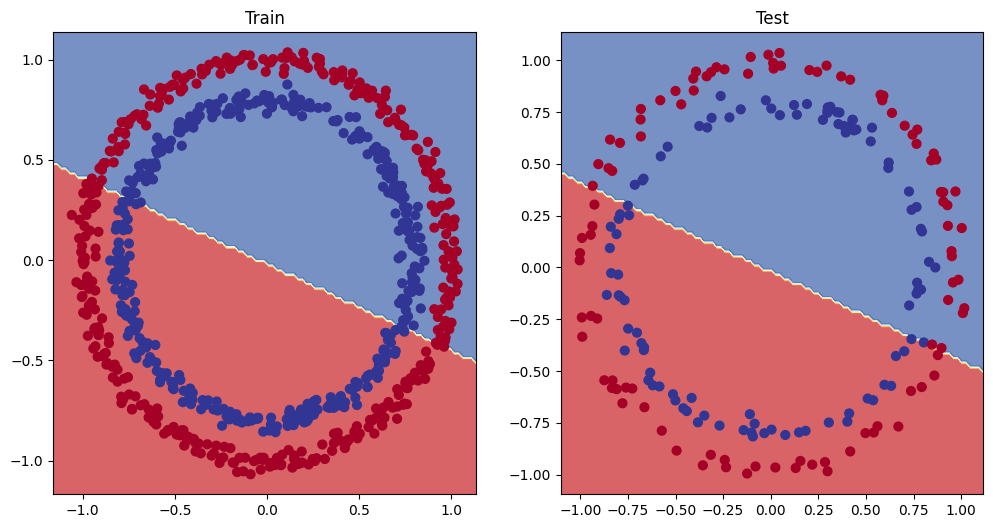

In [120]:
#plot decision noundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test,y_test)


##5 Improving a model( from a model perspective)

* Add more layers - give the model more chances to learn about patterns in the data
* Add more hidden units = go from 5 hidden units to 10 hidden units
* Fit for longer
* changing activation FunctionS
* change the learning rate
* change the loss function

These options are all from a models perspective because theey deal directly with the model, rather than the data.

And because these options are all values we (As machine learning engineers and data scientists) can change , they are referred as **hyperparameters**

In [136]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2,out_features=10)
    self.layer_2 = nn.Linear(in_features=10,out_features=10)
    self.layer_3 = nn.Linear(in_features=10,out_features=1)

  def forward(self,x):
    return self.layer_3(self.layer_2(self.layer_1(x)))


model_1 = CircleModelV1()
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [137]:
# Create a loss function
loss_fn =nn.BCEWithLogitsLoss()

#Create an optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),lr=0.1)

In [138]:
X_train.device

device(type='cuda', index=0)

In [144]:
#training and evaluation loop for model_1
torch.manual_seed(42)

torch.cuda.manual_seed(42)
epochs =1000
model_1.to(device)
X_train,y_train=X_train.to(device),y_train.to(device)
X_test,y_test=X_test.to(device),y_test.to(device)

for epoch in range(epochs):
  model_1.train()
  #forward pass
  y1_logits_ = model_1(X_train).squeeze()
  y1_preds = torch.round(torch.sigmoid(y1_logits_))
  #loss_fn
  loss1= loss_fn(y1_logits_,y_train)
  acc =accuracy_fn(y_true=y_train,
                   y_pred = y_pred)
  #zero_gradient
  optimizer.zero_grad()
  #back propagation
  loss1.backward()
  #optimizer
  optimizer.step()

  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))
    #cal loss
    test_loss = loss_fn(test_logits,
                        test_preds)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred = test_preds)

  #print out whats happening
  if epoch %100 ==0:
    print(f"Epoch:{epoch} | Loss: {loss1:.5f},Acc:{acc:.2f}% | test loss: {test_loss:.5f},| test acc:{test_acc:.2f}%")


Epoch:0 | Loss: 0.69528,Acc:51.38% | test loss: 0.65170,| test acc:50.50%
Epoch:100 | Loss: 0.69325,Acc:51.38% | test loss: 0.68788,| test acc:51.00%
Epoch:200 | Loss: 0.69309,Acc:51.38% | test loss: 0.68919,| test acc:46.50%
Epoch:300 | Loss: 0.69303,Acc:51.38% | test loss: 0.68481,| test acc:47.50%
Epoch:400 | Loss: 0.69300,Acc:51.38% | test loss: 0.68186,| test acc:46.50%
Epoch:500 | Loss: 0.69299,Acc:51.38% | test loss: 0.67990,| test acc:46.00%
Epoch:600 | Loss: 0.69298,Acc:51.38% | test loss: 0.67860,| test acc:46.00%
Epoch:700 | Loss: 0.69298,Acc:51.38% | test loss: 0.67776,| test acc:45.50%
Epoch:800 | Loss: 0.69298,Acc:51.38% | test loss: 0.67720,| test acc:44.50%
Epoch:900 | Loss: 0.69298,Acc:51.38% | test loss: 0.67684,| test acc:45.00%


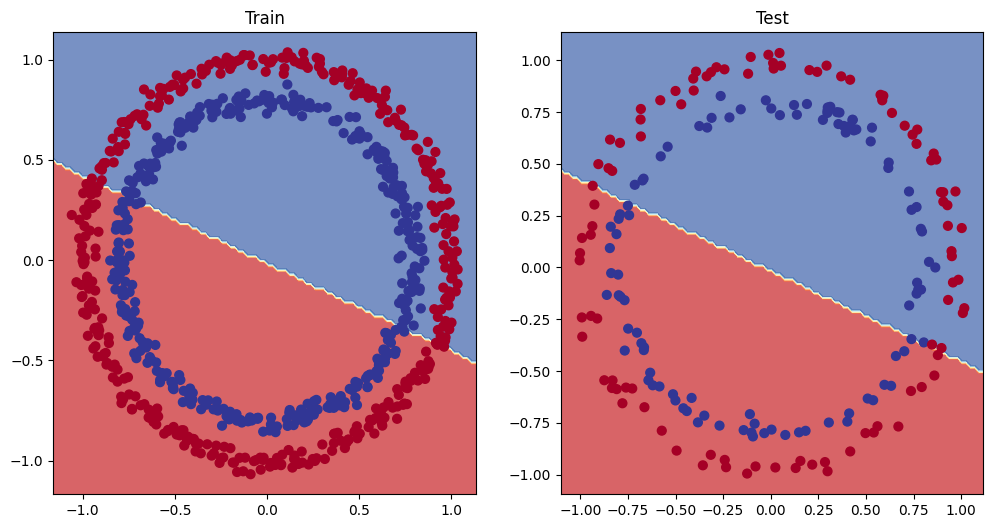

In [145]:
#plot the decision boundary
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1,X_test,y_test)

##5.1 checking if our model learn anything of any type

one way to troubleshoot to a larger problem is to set out a smaller problem

In [161]:
weight =0.7
bias =0.3
start =0
stop =1
step=0.01

X_reg = torch.arange(start,stop,step).unsqueeze(dim=1)
y_reg=weight*X_reg + bias

X_reg[:5],y_reg[:5]

(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [174]:
train_split = int(len(X_reg)*0.8)
X_train_reg,y_train_reg = X_reg[:train_split],y_reg[:train_split]
X_test_reg,y_test_reg = X_reg[train_split:],y_reg[train_split:]
len(X_train_reg),len(X_test_reg )


(80, 20)

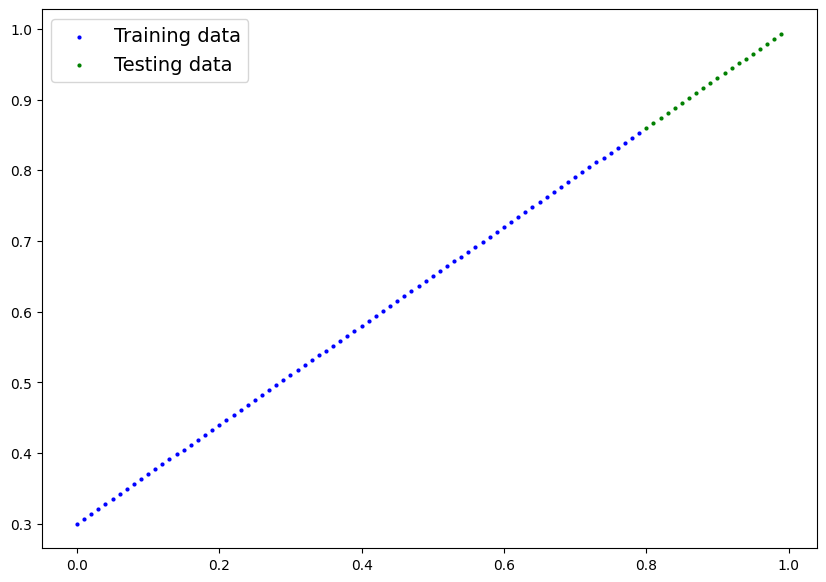

In [175]:
plot_predictions(train_data=X_train_reg,
                 train_labels = y_train_reg,
                 test_data = X_test_reg,
                 test_labels = y_test_reg)

In [176]:
model_testing = CircleModelV1()
model_testing

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

##5.2 need to adjust model to fit straight line

In [178]:
#same architecture as model_1(but using nn.Sequential())
model_2 = nn.Sequential(
    nn.Linear(in_features=1,out_features=10),
    nn.Linear(in_features=10,out_features=10),
    nn.Linear(in_features=10,out_features=1)
).to(device)
model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [187]:
#loss and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params =model_2.parameters(),
                            lr=0.01)

In [188]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs=1000
model_2.to(device)
X_train_reg,y_train_reg = X_train_reg.to(device),y_train_reg.to(device)
X_test_reg,y_test_reg = X_test_reg.to(device),y_test_reg.to(device)
#training
for epoch in range (epochs):
  model_2.train()
  #forward pass
  y_pred_reg = model_2(X_train_reg)
  #loss cal
  loss_val_testing_model = loss_fn(y_pred_reg,y_train_reg)
  #zero grad
  optimizer.zero_grad()
  #back propagation
  loss_val_testing_model.backward()
  #optimizer
  optimizer.step()

#testing
  model_2.eval()
  with torch.inference_mode():
    test_pred_reg = model_2(X_test_reg)
    test_loss_reg = loss_fn(test_pred_reg , y_test_reg)

  #print out what is happening
  if epoch %100==0:
    print(f"Epoch:{epoch} | loss : {loss_val_testing_model:.5f} | test_loss : {test_loss_reg:.5f}")


Epoch:0 | loss : 0.04360 | test_loss : 0.02726
Epoch:100 | loss : 0.00276 | test_loss : 0.00636
Epoch:200 | loss : 0.00548 | test_loss : 0.00071
Epoch:300 | loss : 0.00606 | test_loss : 0.00131
Epoch:400 | loss : 0.00603 | test_loss : 0.00108
Epoch:500 | loss : 0.00600 | test_loss : 0.00109
Epoch:600 | loss : 0.00626 | test_loss : 0.00110
Epoch:700 | loss : 0.00623 | test_loss : 0.00110
Epoch:800 | loss : 0.00620 | test_loss : 0.00110
Epoch:900 | loss : 0.00632 | test_loss : 0.00151


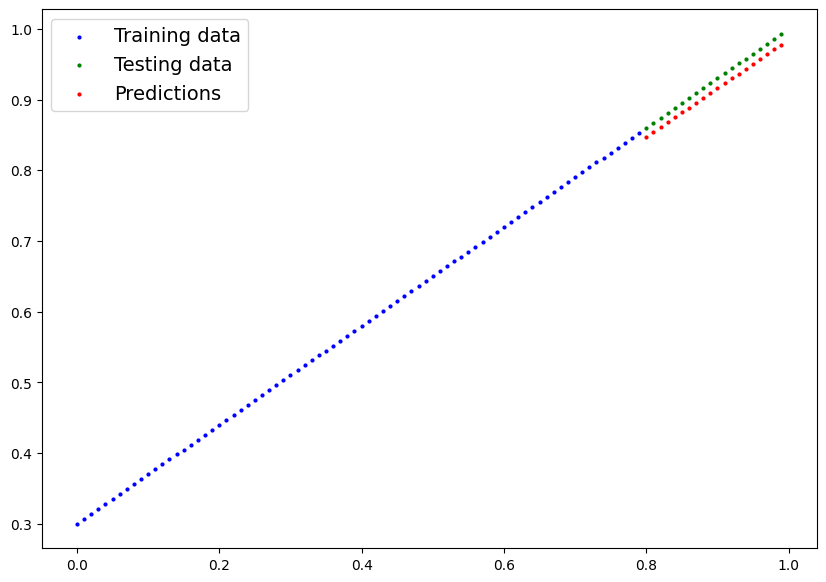

In [197]:
#making some predictions
model_2.eval()
with torch.inference_mode():
  y_pred_regs= model_2(X_test_reg)
  loss_value_reg = loss_fn(y_pred_regs,y_test_reg)

plot_predictions(train_data = X_train_reg.cpu(),
                  train_labels = y_train_reg.cpu(),
                  test_data = X_test_reg.cpu(),
                  test_labels = y_test_reg.cpu(),
                  predictions=y_pred_regs.cpu(),
                  )